## Step 1 — Load and understand the data

In [28]:
import pandas as pd
df = pd.read_csv("Bassac_01.csv", nrows=2000)
df


,Date,WL
0,19/06/2020 12:00,1.18
1,19/06/2020 12:15,1.16
2,19/06/2020 12:30,1.14
3,19/06/2020 12:45,1.12
4,19/06/2020 13:00,1.10
...,...,...
1995,10/07/2020 06:45,1.35
1996,10/07/2020 07:00,1.33
1997,10/07/2020 07:15,1.32
1998,10/07/2020 07:30,1.30


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2000 non-null   str    
 1   WL      2000 non-null   float64
dtypes: float64(1), str(1)
memory usage: 31.4 KB


In [30]:
df.isnull().sum()

Date    0
WL      0
dtype: int64

In [31]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2000 non-null   datetime64[us]
 1   WL      2000 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 31.4 KB


In [33]:
df = df.sort_values("Date").reset_index(drop=True)

In [34]:
df

,Date,WL
0,2020-06-19 12:00:00,1.18
1,2020-06-19 12:15:00,1.16
2,2020-06-19 12:30:00,1.14
3,2020-06-19 12:45:00,1.12
4,2020-06-19 13:00:00,1.10
...,...,...
1995,2020-07-10 06:45:00,1.35
1996,2020-07-10 07:00:00,1.33
1997,2020-07-10 07:15:00,1.32
1998,2020-07-10 07:30:00,1.30


In [35]:
df.duplicated().sum()

np.int64(0)

## Step 2: Create the target variable

In [36]:
# Target the water lavel we want to predict
df["target"] = df["WL"].shift(-1)

#Drop NaN of the target column
df = df.dropna(subset=["target"])
df

,Date,WL,target
0,2020-06-19 12:00:00,1.18,1.16
1,2020-06-19 12:15:00,1.16,1.14
2,2020-06-19 12:30:00,1.14,1.12
3,2020-06-19 12:45:00,1.12,1.10
4,2020-06-19 13:00:00,1.10,1.08
...,...,...,...
1994,2020-07-10 06:30:00,1.36,1.35
1995,2020-07-10 06:45:00,1.35,1.33
1996,2020-07-10 07:00:00,1.33,1.32
1997,2020-07-10 07:15:00,1.32,1.30


## Step Create Lag feature


In [37]:
df["lag_2"] = df["WL"].shift(2)
df["lag_4"] = df["WL"].shift(4)
df["lag_8"] = df["WL"].shift(8)
df["lag_12"] = df["WL"].shift(12)
df["lag_24"] = df["WL"].shift(24)

In [38]:
df

,Date,WL,target,lag_2,lag_4,lag_8,lag_12,lag_24
0,2020-06-19 12:00:00,1.18,1.16,NaN,NaN,NaN,NaN,NaN
1,2020-06-19 12:15:00,1.16,1.14,NaN,NaN,NaN,NaN,NaN
2,2020-06-19 12:30:00,1.14,1.12,1.18,NaN,NaN,NaN,NaN
3,2020-06-19 12:45:00,1.12,1.10,1.16,NaN,NaN,NaN,NaN
4,2020-06-19 13:00:00,1.10,1.08,1.14,1.18,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1994,2020-07-10 06:30:00,1.36,1.35,1.40,1.42,1.48,1.51,1.73
1995,2020-07-10 06:45:00,1.35,1.33,1.38,1.40,1.46,1.50,1.72
1996,2020-07-10 07:00:00,1.33,1.32,1.36,1.40,1.44,1.49,1.69
1997,2020-07-10 07:15:00,1.32,1.30,1.35,1.38,1.43,1.49,1.66


In [ ]:

import matplotlib.pyplot as plt


<Figure size 900x3000 with 0 Axes>

<Figure size 900x3000 with 0 Axes>

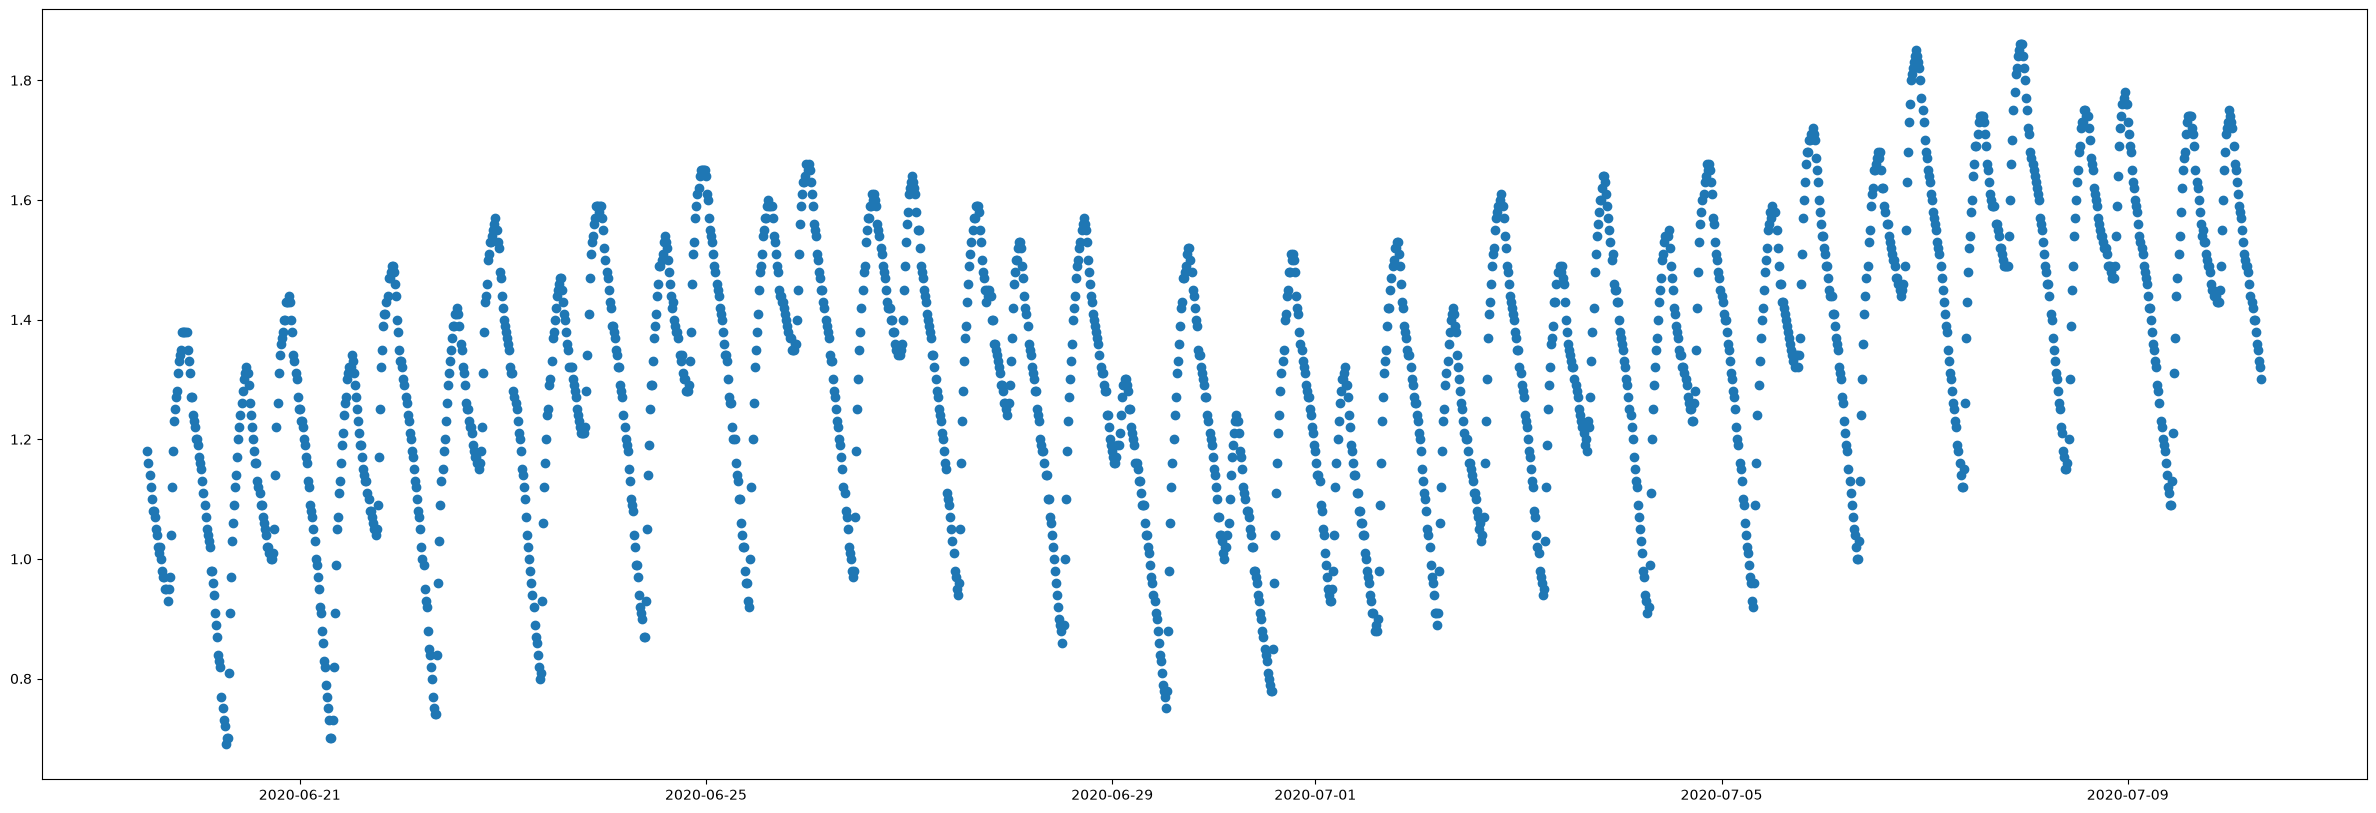

In [49]:
plt.figure(figsize=(30, 10))
plt.scatter(df["Date"], df["WL"])